# Part 2 — RFM Segmentation & Retention Strategy
**D2C Customer Churn Capstone**

Snapshot date: `2025-09-30` | 2,400 customers | 8 segments

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = './'
rfm_raw   = pd.read_csv(f'{DATA_DIR}rfm_modeling_snapshot.csv', parse_dates=['snapshot_date'])
intv      = pd.read_csv(f'{DATA_DIR}intervention_history.csv')

df = rfm_raw.merge(intv[['customer_id','last_campaign_received','manual_priority_bucket']],
                   on='customer_id', how='left')
print(f'Dataset shape: {df.shape}')
print(f'Overall churn rate: {df["churn_next_60d"].mean():.1%}')

Dataset shape: (2400, 31)
Overall churn rate: 47.0%


## 1. RFM Feature Summary

,recency_days,frequency_180d,monetary_180d
count,2400.00,2400.00,2400.00
mean,87.38,1.59,1179.76
std,80.14,1.18,1035.90
min,0.00,0.00,0.00
25%,25.00,1.00,449.27
50%,66.00,1.00,911.88
75%,129.00,2.00,1681.51
max,562.00,8.00,6982.41


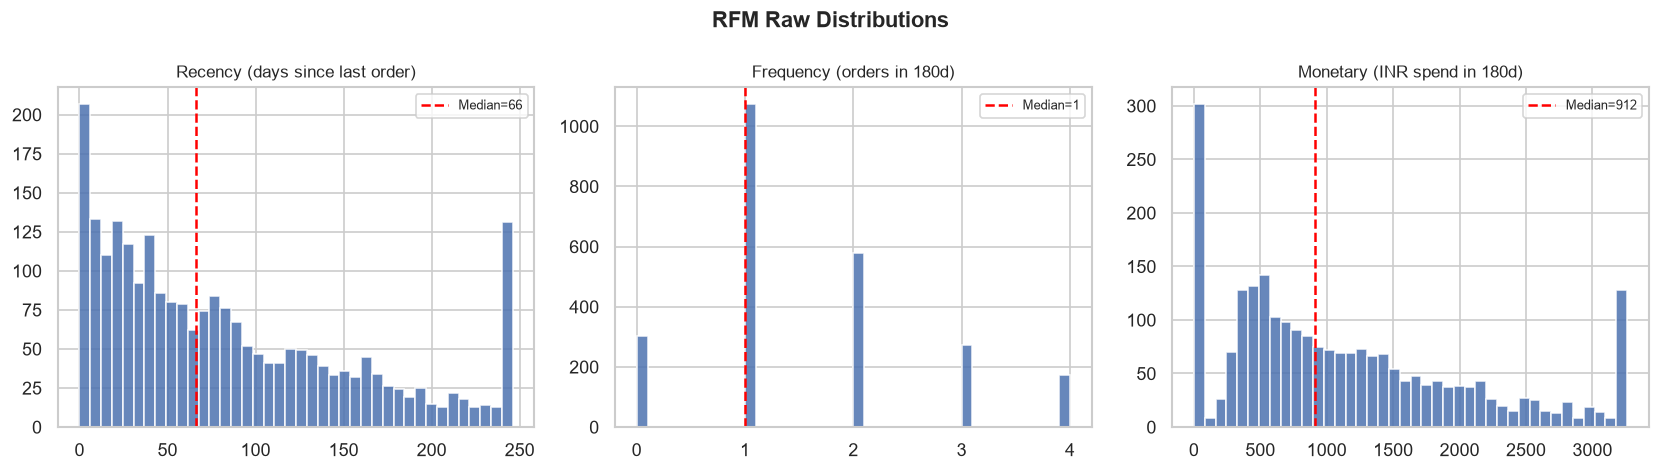

In [2]:
rfm_cols = ['recency_days', 'frequency_180d', 'monetary_180d']
display(df[rfm_cols].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['Recency (days since last order)', 'Frequency (orders in 180d)', 'Monetary (INR spend in 180d)']
for ax, col, title in zip(axes, rfm_cols, titles):
    ax.hist(df[col].clip(upper=df[col].quantile(0.95)), bins=40,
            color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.axvline(df[col].median(), color='red', linestyle='--', label=f'Median={df[col].median():.0f}')
    ax.legend(fontsize=8)
plt.suptitle('RFM Raw Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_chart0_distributions.png')
plt.show()

## 2. RFM Scoring (1–5 scale)

- **R score**: 5 = ordered very recently, 1 = ordered long ago
- **F score**: 5 = ordered very frequently, 1 = rarely ordered
- **M score**: 5 = highest spenders, 1 = lowest spenders

RFM score distribution:
count    2400.00
mean        9.01
std         3.51
min         3.00
25%         7.00
50%         9.00
75%        12.00
max        15.00
Name: RFM_score, dtype: float64


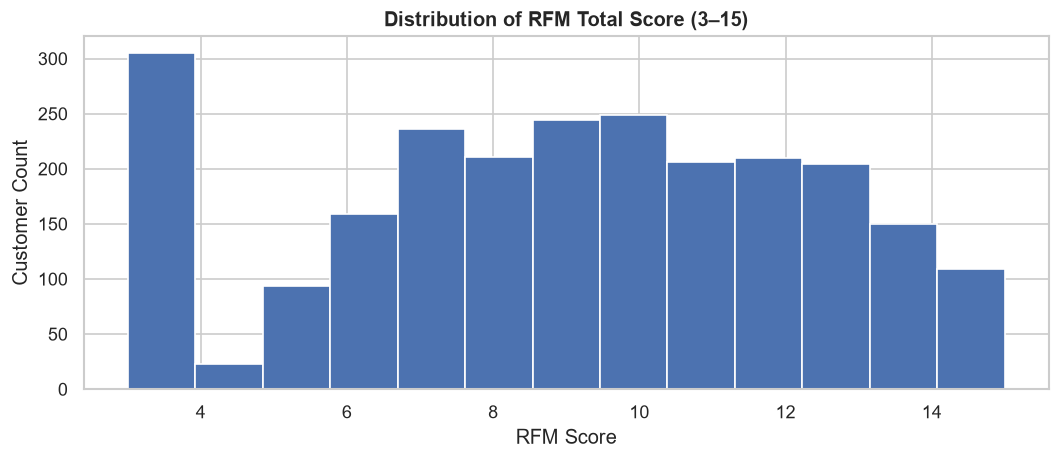

In [3]:
# Recency: lower days = better customer = higher score → reverse labels
df['R'] = pd.qcut(df['recency_days'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency and Monetary: higher = better → ascending labels
# Use rank(method='first') to handle ties in low-cardinality columns
df['F'] = pd.qcut(df['frequency_180d'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
df['M'] = pd.qcut(df['monetary_180d'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

df['RFM_score'] = df['R'] + df['F'] + df['M']  # range: 3 to 15

print('RFM score distribution:')
print(df['RFM_score'].describe().round(2))

fig, ax = plt.subplots(figsize=(9, 4))
df['RFM_score'].hist(bins=13, color='#4C72B0', edgecolor='white', ax=ax)
ax.set_title('Distribution of RFM Total Score (3–15)', fontsize=12, fontweight='bold')
ax.set_xlabel('RFM Score')
ax.set_ylabel('Customer Count')
plt.tight_layout()
plt.savefig('rfm_chart_score_dist.png')
plt.show()

## 3. Segment Assignment

Eight segments based on RFM scores + behavioural signals:

| Segment | Logic |
|---|---|
| Champions | R≥4, F≥4, M≥4 — best customers |
| Loyal Customers | R≥3, F≥3, RFM≥9 — consistent buyers |
| Promising New | R≥4, F≤2 — recently acquired, not yet frequent |
| At-Risk | R≤2, F≥3 — used to buy often, now quiet |
| Dormant | R≤2, F≤2, recency>150d — haven't engaged in months |
| Discount Sensitive | avg_discount≥35%, RFM<10 — buy mainly on promotion |
| High Value Unhappy | tickets≥2, M≥3 — high spenders with complaints |
| Silent Disengaged | 0 sessions + recency>60d — invisible online |
| Needs Attention | All others — mid-tier, no strong signal |

In [4]:
def assign_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    rfm_s   = row['RFM_score']
    disc    = row['avg_discount_pct_180d']
    tickets = row['ticket_count_90d']
    sessions = row['sessions_30d']
    recency  = row['recency_days']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and rfm_s >= 9:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Promising New'
    elif r <= 2 and f >= 3:
        return 'At-Risk'
    elif r <= 2 and f <= 2 and recency > 150:
        return 'Dormant'
    elif disc >= 0.35 and rfm_s < 10:
        return 'Discount Sensitive'
    elif tickets >= 2 and m >= 3:
        return 'High Value Unhappy'
    elif sessions == 0 and recency > 60:
        return 'Silent Disengaged'
    else:
        return 'Needs Attention'

df['segment_name'] = df.apply(assign_segment, axis=1)

print('Customers per segment:')
print(df['segment_name'].value_counts())
print('\nChurn rate per segment:')
print(df.groupby('segment_name')['churn_next_60d'].mean().sort_values(ascending=False).map('{:.1%}'.format))

Customers per segment:
segment_name
Loyal Customers       578
Champions             401
At-Risk               390
Dormant               372
Promising New         265
Needs Attention       245
Discount Sensitive    130
Silent Disengaged      19
Name: count, dtype: int64

Churn rate per segment:
segment_name
Dormant               91.1%
Silent Disengaged     84.2%
At-Risk               72.1%
Needs Attention       66.1%
Discount Sensitive    63.8%
Loyal Customers       25.4%
Promising New         21.9%
Champions             10.2%
Name: churn_next_60d, dtype: str


## 4. Segment Visualisations

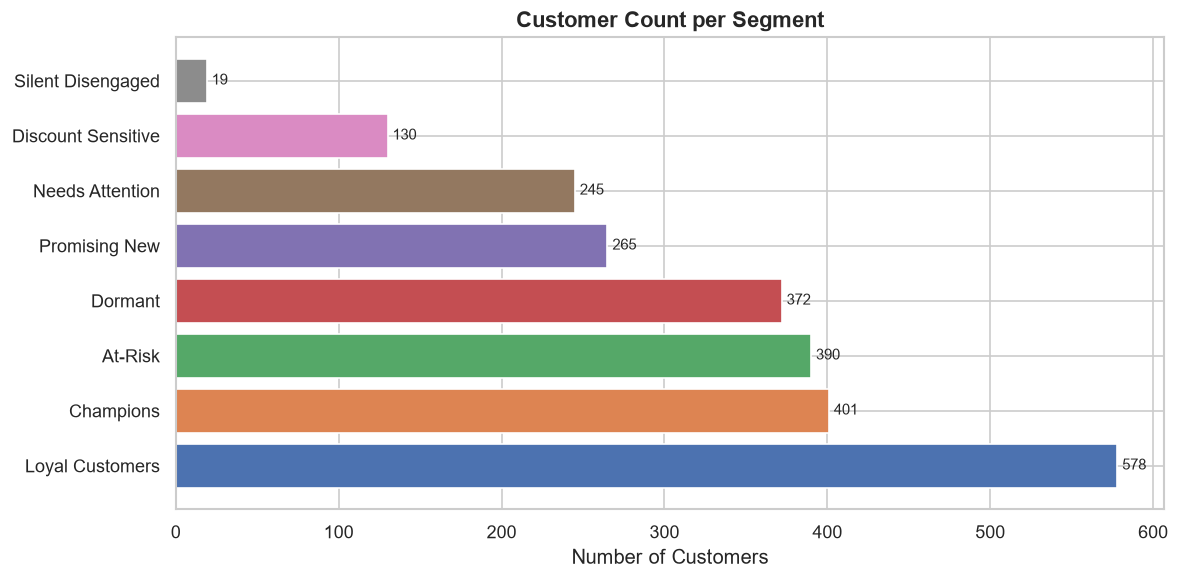

In [5]:
# Chart 1: Segment sizes
seg_counts = df['segment_name'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3','#8C8C8C']
bars = ax.barh(seg_counts.index, seg_counts.values, color=colors)
for bar in bars:
    ax.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
ax.set_title('Customer Count per Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Customers')
plt.tight_layout()
plt.savefig('rfm_chart1_segment_sizes.png')
plt.show()

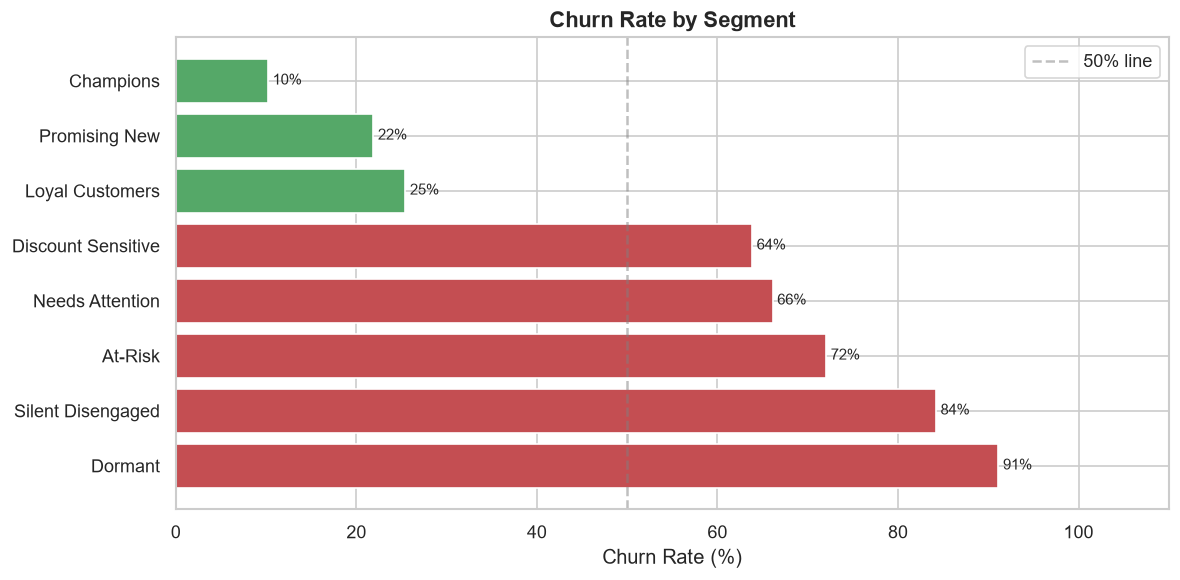

In [6]:
# Chart 2: Churn rate per segment
churn_rate = df.groupby('segment_name')['churn_next_60d'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#C44E52' if v > 0.6 else '#DD8452' if v > 0.3 else '#55A868' for v in churn_rate.values]
bars = ax.barh(churn_rate.index, churn_rate.values * 100, color=bar_colors)
for bar in bars:
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.0f}%', va='center', fontsize=9)
ax.set_title('Churn Rate by Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
ax.set_xlim(0, 110)
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50% line')
ax.legend()
plt.tight_layout()
plt.savefig('rfm_chart2_churn_by_segment.png')
plt.show()

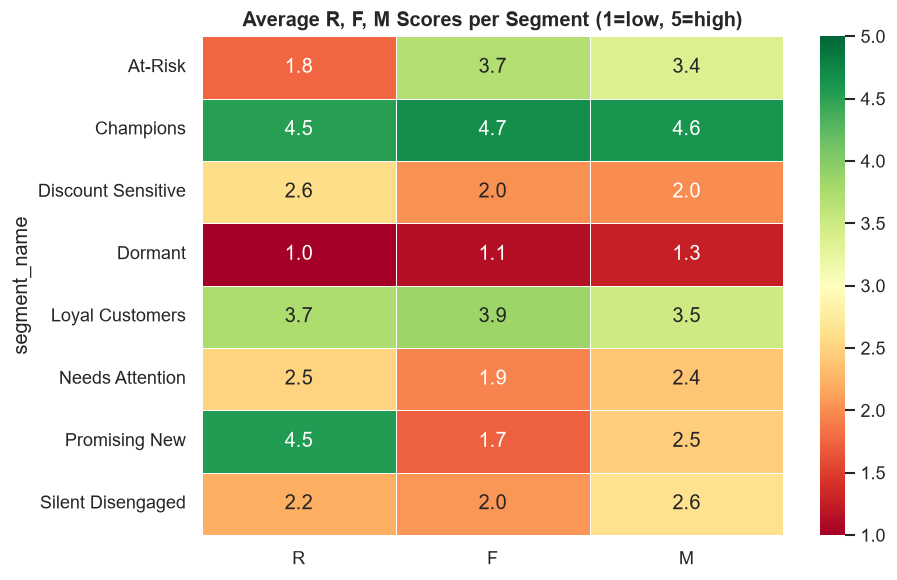

In [7]:
# Chart 3: RFM score heatmap per segment
seg_rfm = df.groupby('segment_name')[['R','F','M']].mean().round(2)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(seg_rfm, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, vmin=1, vmax=5)
ax.set_title('Average R, F, M Scores per Segment (1=low, 5=high)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_chart3_rfm_heatmap.png')
plt.show()

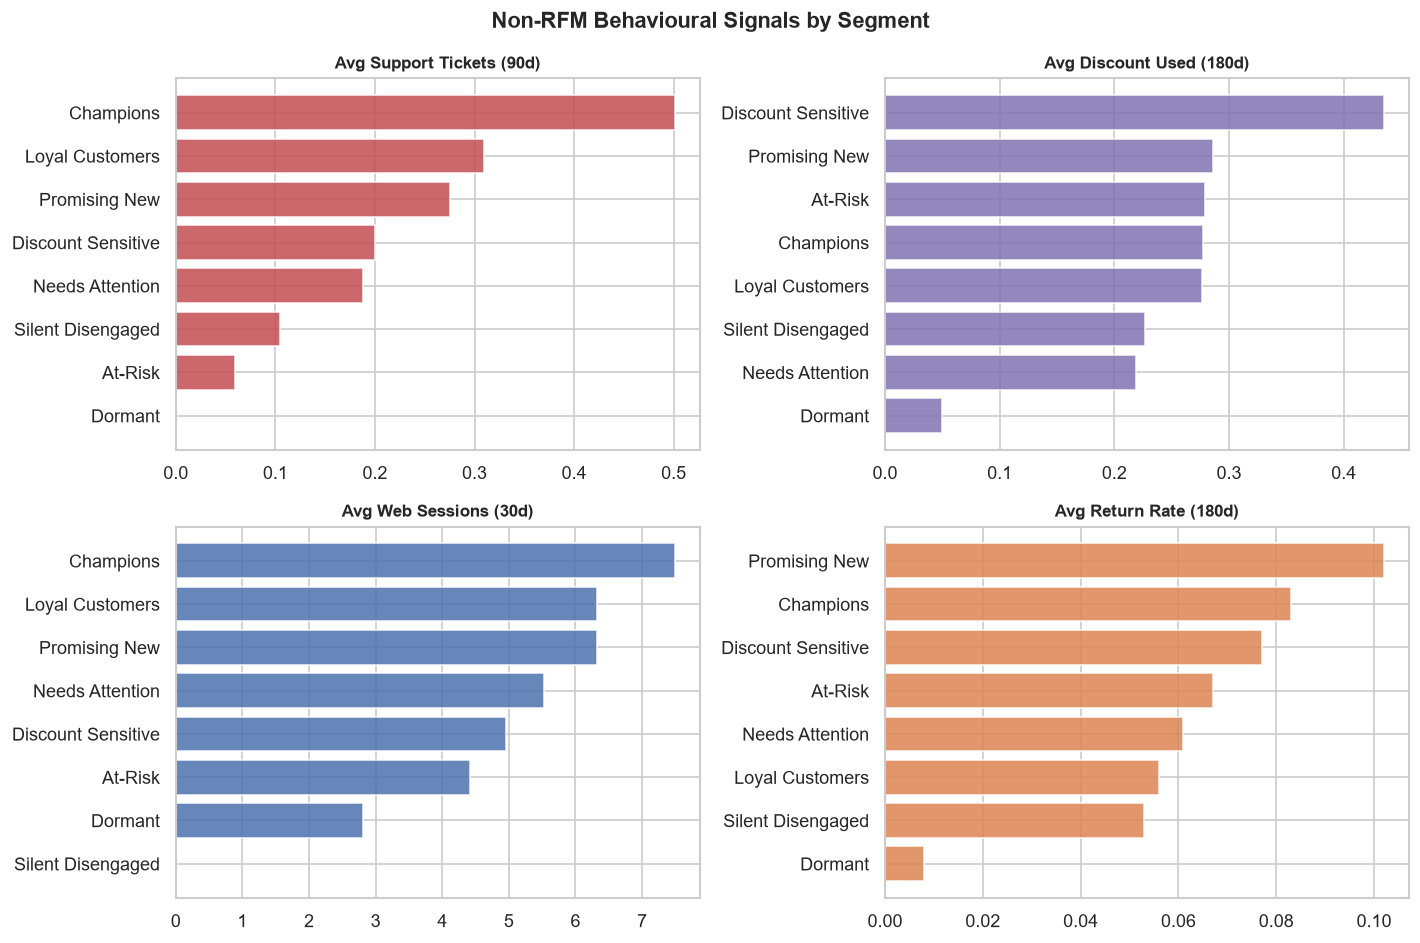

In [8]:
# Chart 4: Non-RFM signals by segment
sig_cols = ['ticket_count_90d', 'avg_discount_pct_180d', 'sessions_30d', 'return_rate_180d']
sig_df = df.groupby('segment_name')[sig_cols].mean().round(3)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
signal_info = [
    ('ticket_count_90d',       'Avg Support Tickets (90d)',   '#C44E52'),
    ('avg_discount_pct_180d',  'Avg Discount Used (180d)',    '#8172B2'),
    ('sessions_30d',           'Avg Web Sessions (30d)',      '#4C72B0'),
    ('return_rate_180d',       'Avg Return Rate (180d)',      '#DD8452'),
]
for ax, (col, title, color) in zip(axes.flatten(), signal_info):
    vals = sig_df[col].sort_values(ascending=True)
    ax.barh(vals.index, vals.values, color=color, alpha=0.85)
    ax.set_title(title, fontsize=10, fontweight='bold')
plt.suptitle('Non-RFM Behavioural Signals by Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_chart4_nonrfm_signals.png')
plt.show()

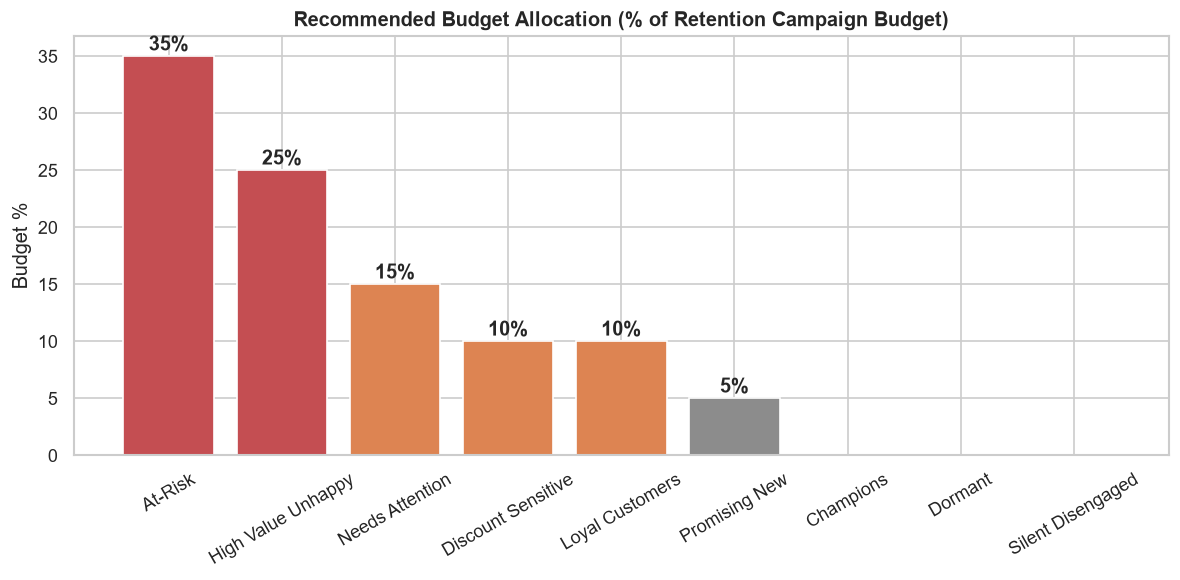

In [9]:
# Chart 5: Recommended budget allocation
budget = {
    'At-Risk': 35, 'High Value Unhappy': 25, 'Needs Attention': 15,
    'Discount Sensitive': 10, 'Loyal Customers': 10, 'Promising New': 5,
    'Champions': 0, 'Dormant': 0, 'Silent Disengaged': 0
}
segs = list(budget.keys())
vals = list(budget.values())
bar_c = ['#C44E52' if v >= 25 else '#DD8452' if v >= 10 else '#8C8C8C' for v in vals]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(segs, vals, color=bar_c)
ax.set_title('Recommended Budget Allocation (% of Retention Campaign Budget)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Budget %')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(vals):
    if v > 0:
        ax.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_chart5_budget.png')
plt.show()

## 5. Save segments.csv

In [10]:
seg_cols = [
    'customer_id', 'segment_name', 'R', 'F', 'M', 'RFM_score',
    'recency_days', 'frequency_180d', 'monetary_180d',
    'ticket_count_90d', 'avg_discount_pct_180d', 'sessions_30d',
    'return_rate_180d', 'negative_ticket_rate_90d', 'last_visit_days_ago',
    'last_campaign_received', 'manual_priority_bucket', 'churn_next_60d'
]
df[seg_cols].to_csv('segments.csv', index=False)
print('segments.csv saved.')
print(f'Shape: {df[seg_cols].shape}')
display(df[seg_cols].head(3))

segments.csv saved.
Shape: (2400, 18)


,customer_id,segment_name,R,F,M,RFM_score,recency_days,frequency_180d,monetary_180d,ticket_count_90d,avg_discount_pct_180d,sessions_30d,return_rate_180d,negative_ticket_rate_90d,last_visit_days_ago,last_campaign_received,manual_priority_bucket,churn_next_60d
0,CUST00001,Needs Attention,2,1,1,4,107,1,362.73,0,0.23,1,0.0,0.0,20,welcome_offer,high,1
1,CUST00002,Promising New,4,1,2,7,40,1,581.00,1,0.23,8,0.0,0.0,0,free_shipping,medium,0
2,CUST00003,Dormant,1,1,2,4,171,1,649.98,0,0.47,1,0.0,0.0,26,none,high,1
